In [1]:
!pip install pandas
!pip install requests
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [4]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [5]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [6]:
Tesla=yf.Ticker("TSLA")

In [7]:
tesla_data=Tesla.history(period="max")

In [9]:
tesla_data.reset_index(inplace=True)
tesla_data.head()

,index,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [10]:
tesla_data.tail()

,index,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
4027,4027,2026-07-06 00:00:00-04:00,397.500000,420.000000,390.500000,419.769989,54727900,0.0,0.0
4028,4028,2026-07-07 00:00:00-04:00,416.959991,419.559998,401.880005,402.899994,38149900,0.0,0.0
4029,4029,2026-07-08 00:00:00-04:00,399.380005,399.630005,390.510010,394.059998,33844900,0.0,0.0
4030,4030,2026-07-09 00:00:00-04:00,393.989990,407.859985,390.859985,406.549988,37835000,0.0,0.0
4031,4031,2026-07-10 00:00:00-04:00,410.489990,413.160004,402.809998,407.760010,33342700,0.0,0.0


In [11]:
import requests
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data=requests.get(url).text

In [12]:
from bs4 import BeautifulSoup
soup=BeautifulSoup(html_data,'html.parser')
import pandas as pd
tesla_revenue=pd.DataFrame(columns=["Date","Revenue"])

In [14]:
for row in soup.find_all("tbody")[1].find_all('tr'):
    col=row.find_all('td')
    date=col[0].text
    revenue=col[1].text
    tesla_revenue=pd.concat([tesla_revenue,pd.DataFrame({"Date":[date],"Revenue":[revenue]})],ignore_index=True)

In [15]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)

In [16]:
tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

In [17]:
tesla_revenue.head()

,Date,Revenue
0,2022-09-30,21454
1,2022-06-30,16934
2,2022-03-31,18756
3,2021-12-31,17719
4,2021-09-30,13757


In [18]:
tesla_revenue.tail()

,Date,Revenue
102,2010-09-30,31
103,2010-06-30,28
104,2010-03-31,21
106,2009-09-30,46
107,2009-06-30,27


In [19]:
GameStop=yf.Ticker("GME")

In [20]:
gme_data=GameStop.history(period="max")

In [21]:
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [22]:
import requests
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2=requests.get(url).text

In [23]:
from bs4 import BeautifulSoup
soup=BeautifulSoup(html_data_2,'html.parser')

In [25]:

gme_revenue=pd.DataFrame(columns=["Date","Revenue"])
for row in soup.find_all("tbody")[1].find_all('tr'):
    col=row.find_all('td')
    date=col[0].text
    revenue=col[1].text
    gme_revenue=pd.concat([gme_revenue,pd.DataFrame({"Date":[date],"Revenue":[revenue]})],ignore_index=True)

In [26]:
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"",regex=True)
gme_revenue.dropna(inplace=True)

gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

In [27]:
gme_revenue.head()

,Date,Revenue
0,2020-04-30,1021
1,2020-01-31,2194
2,2019-10-31,1439
3,2019-07-31,1286
4,2019-04-30,1548


In [28]:
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


In [29]:


import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

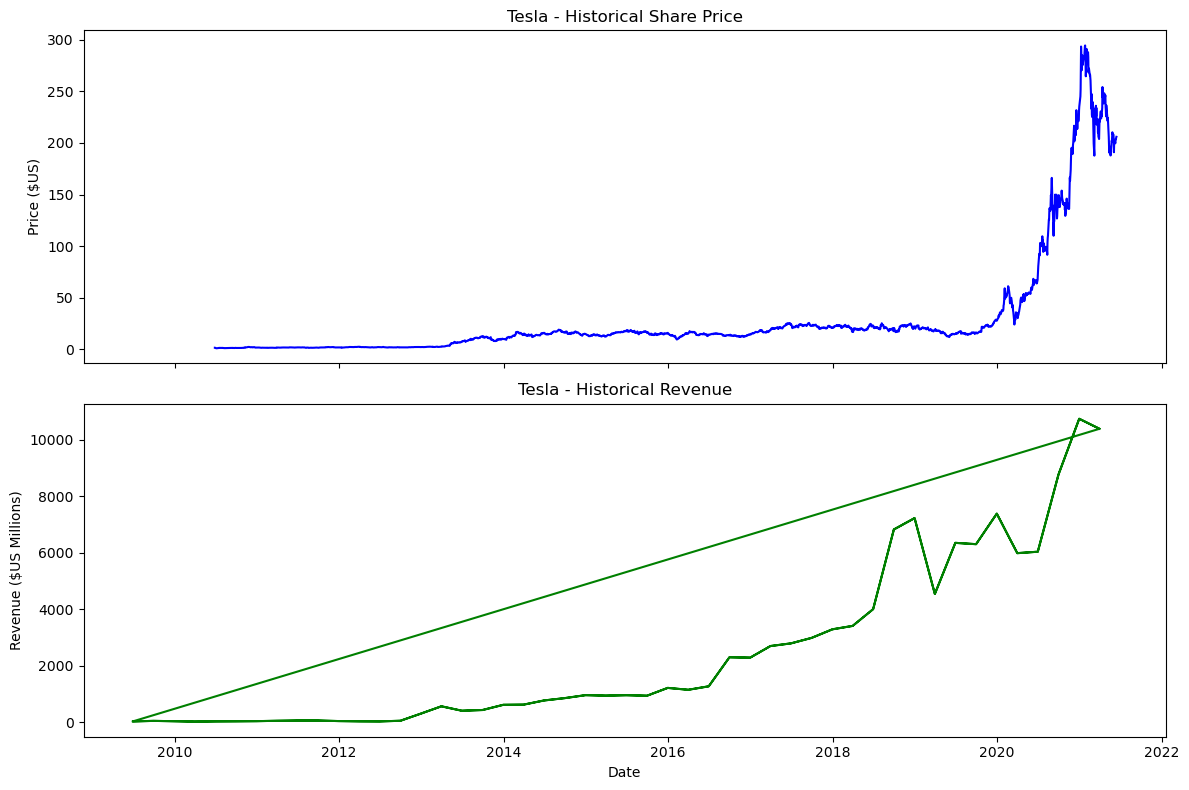

In [30]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

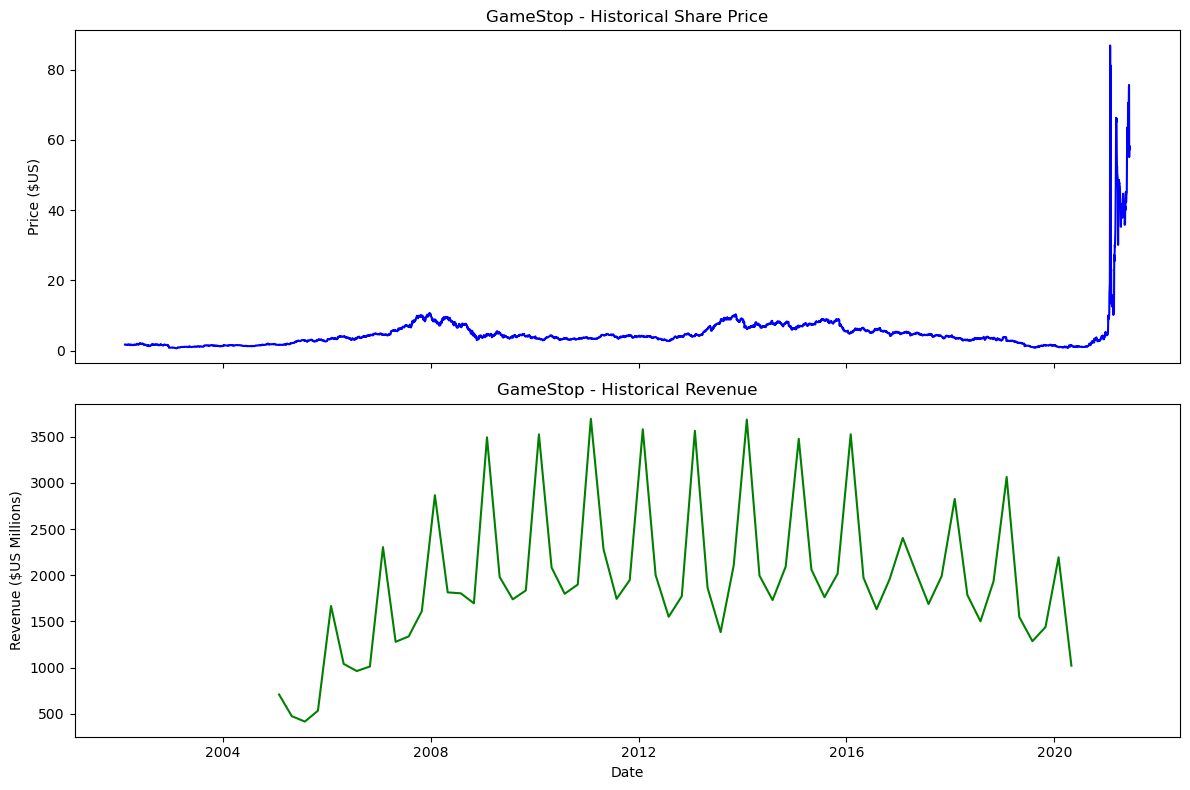

In [32]:
make_graph(gme_data, gme_revenue, 'GameStop')
